In [2]:
from ising_model import PairwiseIsingModelInferencer, PairwiseIsingModel, ConfigurationIterator
import numpy as np

In [3]:
n_sites = 12
ising_model = PairwiseIsingModel(n_sites)
ising_model.J = np.random.rand(n_sites, n_sites)
ising_model.H = np.random.rand(n_sites)

inferencer = PairwiseIsingModelInferencer(ising_model)
inferencer.update_partition_function()

In [4]:
n_samples = 10000
observation_dataset = np.random.randint(0, 2, (n_samples, n_sites))

In [5]:
from ising_trainer import PairwiseIsingModelTrainer
from tqdm import tqdm
total_epoches = 200
trainer = PairwiseIsingModelTrainer(ising_model, inferencer)
loss_record = []
pbar = tqdm(total=total_epoches, desc="Training", unit="epoch")

def on_epoch_end(ctx):
    epoch = ctx.epoch
    epochs = ctx.epochs
    loss = ctx.loss
    kl_loss = ctx.kl_loss
    l2_loss = ctx.l2_loss
    
    pbar.set_description(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}, KL: {kl_loss:.4f}, L2: {l2_loss:.4f}")
    pbar.update(1) 
    loss_record.append(loss)

trained_model = trainer.train(observation_dataset, epochs=total_epoches, learning_rate=0.01, epoch_callback=on_epoch_end)

Epoch 200/200, Loss: 9.7293, KL: 9.7067, L2: 0.0226: 100%|██████████| 200/200 [00:48<00:00,  2.45epoch/s]  

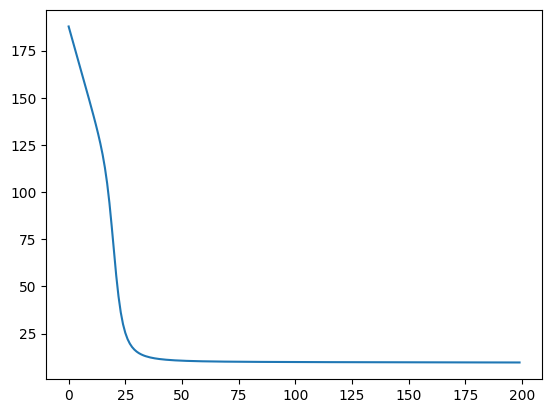

In [6]:
import matplotlib.pyplot as plt
plt.plot(range(total_epoches), loss_record)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_alignment(observation_dataset, inferencer):
    """Plot alignment between observation averages and model averages."""
    n_sites = observation_dataset.shape[1]

    # Compute observation averages
    essembly_average_obs_sisj = np.einsum('ki,kj->ij', observation_dataset, observation_dataset) / observation_dataset.shape[0]
    essembly_average_obs_si = np.mean(observation_dataset, axis=0)

    # Compute model averages
    essembly_average_model_sisj = inferencer.essembly_average_sisj()
    essembly_average_model_si = inferencer.essembly_average_si()

    # Flatten the pairwise correlation matrices for plotting
    obs_sisj_flat = essembly_average_obs_sisj.flatten()
    model_sisj_flat = essembly_average_model_sisj.flatten()

    # Plot pairwise correlations
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(obs_sisj_flat, model_sisj_flat, alpha=0.5)
    plt.plot([0, 1], [0, 1], 'r--')  # y = x line
    plt.xlabel("Observation $\langle s_i s_j \\rangle_{\\text{obs}}$")
    plt.ylabel("Model $\langle s_i s_j \\rangle_{\\text{model}}$")
    plt.title("Pairwise Correlations Alignment")
    plt.xlim([0.,1.])
    plt.ylim([0.,1.])
    
    # Plot single-site averages
    plt.subplot(1, 2, 2)
    plt.scatter(essembly_average_obs_si, essembly_average_model_si, alpha=0.5)
    plt.plot([0, 1], [0, 1], 'r--')  # y = x line
    plt.xlabel("Observation $\langle s_i \\rangle_{\\text{obs}}$")
    plt.ylabel("Model $\langle s_i \\rangle_{\\text{model}}$")
    plt.title("Single-Site Averages Alignment")

    plt.tight_layout()
    plt.xlim([0.,1.])
    plt.ylim([0.,1.])

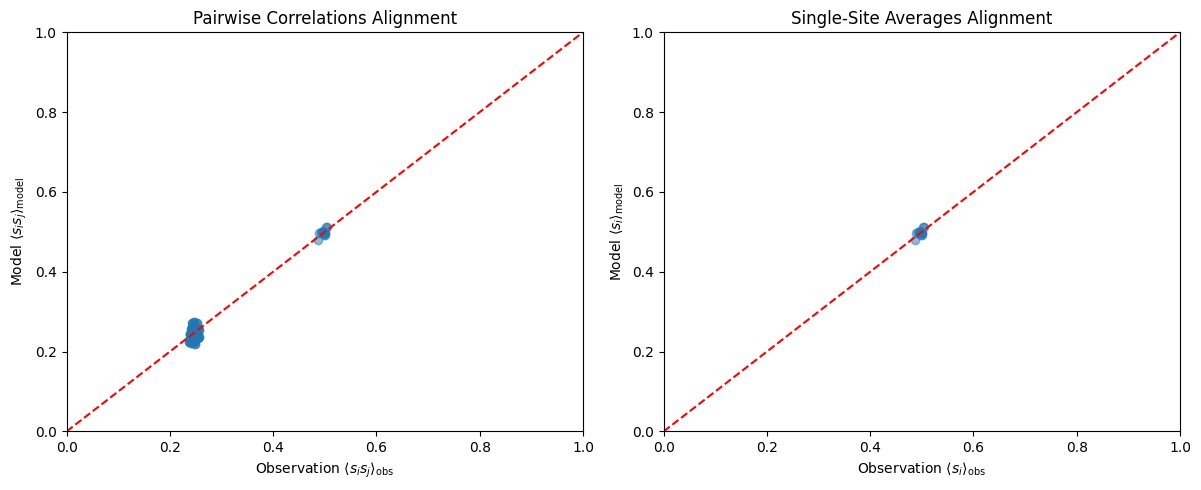

In [ ]:
plot_alignment(observation_dataset, inferencer)

In [8]:
configuration_size = 10
dummay_microstate_sequence = np.random.randint(1, 5, (12 * 100))
dummay_microstate_sequence
n_samples_per_site = 48